In [1]:
from pygenomeviz import GenomeViz
from pygenomeviz.parser import Genbank
from pygenomeviz.utils import load_example_genbank_dataset
from pygenomeviz.align import Blast, AlignCoord, MMseqs
import matplotlib.pyplot as plt 
import tempfile
import os
from IPython.display import Image, display
import textwrap
import seaborn as sns

import numpy as np
import copy
from Bio.SeqFeature import SeqFeature, FeatureLocation
from Bio import SeqIO
import pandas as pd
plt.rcParams.update({'font.size': 14, 'font.family':'Arial'})
import scipy
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.patches import Patch
from matplotlib import cm



In [2]:
def getOverlap(a, b):
    return max(0, min(a[1], b[1]) - max(a[0], b[0]))

In [3]:
ann_dict_simple = {'MG334.mbin.2_00182': 'hypothetical protein (1)',
 'ERR10897979.sbin.2_00762': 'hypothetical protein (2)',
 'ERR10897595.sbin.1_00593': 'hypothetical protein (3)',
 'ERR10897723.sbin.1_00478': 'type II toxin-antitoxin system HicA family toxin',
 'ERR4421622.sbin.2_01193': 'XRE family transcriptional regulator',
 'SRR17635712.mbin.7_01059': 'Na+/H+ antiporter NhaC',
 'ERR10897595.sbin.1_01051': 'hypothetical protein (4)',
 'ERR10897583.sbin.2_00776': 'hypothetical protein (5)',
 'ERR10897696.sbin.1_01201': 'DUF771 domain-containing protein',
 'ERR10897595.sbin.1_00598': 'hypothetical protein (6)',
 'ERR10898139.sbin.1_00313': 'LacI family transcriptional regulator',
 'ERR10897595.sbin.1_00591': 'MarR family transcriptional regulator',
  'ERR10897583.sbin.2_00437': 'type II toxin-antitoxin system HicB family antitoxin',
 }


In [4]:
strain_to_accession = {'2029': 'GCA_000466885.3',
 'CO3MRSI1': 'GCA_003795065.1',
 'AB70': 'GCA_003971565.1',
 'FDAARGOS_743': 'GCA_009730275.1',
 'DC21.1': 'GCA_009769205.1',
 'C25': 'GCA_009933525.1',
 'B4': 'GCA_013456995.1',
 '1D': 'GCA_013487905.1',
 'PRL2021': 'GCA_016767795.1',
 'PMC201': 'GCA_018885325.1',
 'ATCC_33820': 'GCA_018987235.1',
 'Lc1700': 'GCA_020042005.1',
 'Lc1226': 'GCA_020042125.1',
 'Lc116': 'GCA_020042225.1',
 'KT-11': 'GCA_020887095.1',
 'lc83': 'GCA_021278925.1',
 'lc31': 'GCA_021278945.1',
 'M247': 'GCA_026740115.1',
 'Lcr-MH175': 'GCA_027271175.1',
 'VSI04': 'GCA_029011155.1',
 'VSI24': 'GCA_029011475.1',
 'VSI21': 'GCA_029011495.1',
 'VSI17': 'GCA_029011595.1',
 'VSI08': 'GCA_029011765.1',
 'BC1': 'GCA_040109495.1',
 'BC3': 'GCA_041344855.1'}

In [6]:
gbk_files = !ls  genomes_for_pyGenomeViz/*gbff
to_keep = [f'genomes_for_pyGenomeViz/{i}.gbff' for i in strain_to_accession.keys()]
gbk_files = [i for i in gbk_files if i in to_keep]
gbk_list = list(map(Genbank, gbk_files))

In [7]:
len(gbk_list)

26

In [8]:
longest_seq_per_strain = {}
to_skip = []
for gbk in gbk_list:

    longest_seq_name = None
    longest_seq_len = 0

    for seqid, features in gbk.get_seqid2features("CDS").items():
        seq_len = gbk.get_seqid2size()[seqid]
        if seq_len > longest_seq_len:
            longest_seq_len = seq_len
            longest_seq_name = seqid

    #these don't have feature annotations in the GBFF files, will exclude
    if not longest_seq_name:
        to_skip += [gbk.name]
        continue


    longest_seq_per_strain[gbk.name] = longest_seq_name


In [9]:
gbk_list = list(map(Genbank, gbk_files))
gv = GenomeViz(track_align_type="center", fig_track_height=0.5)
gv.set_scale_bar()
to_align = []
total_seq_lens = {}

for gbk in gbk_list:

    if gbk.name not in longest_seq_per_strain:
        continue
    to_align += [gbk]
    seqid = longest_seq_per_strain[gbk.name]
    seq_dict = gbk.get_seqid2features("CDS")
    features = seq_dict[seqid]
    seq_len = gbk.get_seqid2size()[seqid]

    total_seq_lens[gbk.name] = gbk.genome_length

### Load BLAST results

In [10]:
hit_genes = list(ann_dict_simple.keys())

In [11]:
cols = 'query_acc subject_acc pident length qlen qstart qend slen sstart send evalue bitscore'.split(' ')
cols = [i.replace('. ', '.').replace(' ', '_') for i in cols]


blast_results = pd.read_csv('BLAST_NCBI_to_C75/l_crispatus_CDS_to_C75.out', sep='\t', header=None)
blast_results.columns=cols
blast_results = blast_results[(blast_results['pident'] >= 75)]
blast_results['query_cov'] = blast_results['length'] / blast_results['qlen']
blast_results['subject_cov'] = blast_results['length'] / blast_results['slen']
blast_results = blast_results[(blast_results['query_cov'] >= 0.75)]
blast_results = blast_results[(blast_results['subject_cov'] >= 0.75)]



blast_results['contig_name'] = blast_results['query_acc'].str.split('|', expand=True)[1].str.split('_cds', expand=True)[0]
blast_results = blast_results.sort_values('bitscore', ascending=False).drop_duplicates(['contig_name', 'query_acc'])
blast_results = blast_results[blast_results['subject_acc'].isin(hit_genes)]

protein_to_locus_tag = {}

for g in blast_results['query_acc'].tolist():

    cmd = f'grep "{g}" BLAST_NCBI_to_C75/lc_CDS_combined.fna'
    header = !{cmd}
    locus_tag = header[0].split('locus_tag=')[1].split(']')[0]
    protein_to_locus_tag[g] = locus_tag

blast_results['locus_tag'] = blast_results['query_acc'].map(protein_to_locus_tag)
hit_proteins = blast_results['locus_tag'].tolist()
blast_results['annotation'] = blast_results['subject_acc'].map(ann_dict_simple)

blast_results
# blast_results.shape

,query_acc,subject_acc,pident,length,qlen,qstart,qend,slen,sstart,send,evalue,bitscore,query_cov,subject_cov,contig_name,locus_tag,annotation
2190917,lcl|CP157745.1_cds_XBP97485.1_1732,MG334.mbin.2_00182,94.998,2159,2148,1,2147,2160,1,2159,0.000000e+00,3414.0,1.005121,0.999537,CP157745.1,AAFS18_09035,hypothetical protein (1)
826813,lcl|CP076522.1_cds_QWS36480.1_283,MG334.mbin.2_00182,88.889,2160,2148,1,2148,2160,1,2160,0.000000e+00,2820.0,1.005587,1.000000,CP076522.1,KO564_01425,hypothetical protein (1)
207252,lcl|CP026503.1_cds_AZR16373.1_2034,MG334.mbin.2_00182,88.889,2160,2148,1,2148,2160,1,2160,0.000000e+00,2820.0,1.005587,1.000000,CP026503.1,C3K22_10605,hypothetical protein (1)
401189,lcl|CP039266.1_cds_QGY95459.1_1621,MG334.mbin.2_00182,86.985,2159,2148,1,2147,2160,1,2159,0.000000e+00,2625.0,1.005121,0.999537,CP039266.1,E6A57_08505,hypothetical protein (1)
694271,lcl|CP047415.1_cds_QLL74708.1_1986,MG334.mbin.2_00182,86.118,2161,2148,1,2148,2160,1,2160,0.000000e+00,2535.0,1.006052,1.000463,CP047415.1,GTO85_10375,hypothetical protein (1)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162090,lcl|CP026503.1_cds_AZR15460.1_1037,ERR10897583.sbin.2_00776,88.492,252,252,1,252,252,1,252,4.510000e-89,324.0,1.000000,1.000000,CP026503.1,C3K22_05495,hypothetical protein (5)
1306351,lcl|CP083393.1_cds_UAY50308.1_1043,ERR10897583.sbin.2_00776,88.095,252,252,1,252,252,1,252,5.490000e-88,320.0,1.000000,1.000000,CP083393.1,LAE50_05525,hypothetical protein (5)
652224,lcl|CP047415.1_cds_QLL73881.1_1058,ERR10897583.sbin.2_00776,86.905,252,252,1,252,252,1,252,1.210000e-83,306.0,1.000000,1.000000,CP047415.1,GTO85_05635,hypothetical protein (5)
1559743,lcl|CP114552.1_cds_WAZ53461.1_1943,ERR10897583.sbin.2_00776,84.921,252,252,1,252,252,1,252,3.960000e-77,284.0,1.000000,1.000000,CP114552.1,O0957_10135,hypothetical protein (5)


### Map contig names to strains

In [14]:
base_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/code/'
genome_dir = f'{base_dir}/cervical_dysplasia/microSLAM/NCBI_isolates/NCBI_l_crispatus_genomes/ncbi_dataset/data/'
genome_files = !ls {genome_dir}/*/GCA*fna
lc_genome_list = !grep '>' BLAST_NCBI_to_C75/lc_genomes_combined.fna

contig_to_strain = {}

for header in lc_genome_list:
    # print(header)
    contig_name = header.split(' ')[0].replace('>','')
    # print(contig_name)
    
    if 'plasmid' in header:
        strain_name = header.split('Lactobacillus crispatus ')[1].split(' plasmid')[0].split(' DNA')[0].replace('strain ','').replace('isolate ','')
        strain_name = strain_name + '_plasmid'
    else:
        strain_name = header.split('Lactobacillus crispatus ')[1].split(' chromosome')[0].split(' DNA')[0].replace('strain ','').replace('isolate ','')
    contig_to_strain[contig_name] = strain_name

blast_results['strain'] = blast_results['contig_name'].map(contig_to_strain)
blast_results['strain'] = blast_results['strain'].str.replace(' ', '_')
blast_results

,query_acc,subject_acc,pident,length,qlen,qstart,qend,slen,sstart,send,evalue,bitscore,query_cov,subject_cov,contig_name,locus_tag,annotation,strain
2190917,lcl|CP157745.1_cds_XBP97485.1_1732,MG334.mbin.2_00182,94.998,2159,2148,1,2147,2160,1,2159,0.000000e+00,3414.0,1.005121,0.999537,CP157745.1,AAFS18_09035,hypothetical protein (1),BC1
826813,lcl|CP076522.1_cds_QWS36480.1_283,MG334.mbin.2_00182,88.889,2160,2148,1,2148,2160,1,2160,0.000000e+00,2820.0,1.005587,1.000000,CP076522.1,KO564_01425,hypothetical protein (1),PMC201
207252,lcl|CP026503.1_cds_AZR16373.1_2034,MG334.mbin.2_00182,88.889,2160,2148,1,2148,2160,1,2160,0.000000e+00,2820.0,1.005587,1.000000,CP026503.1,C3K22_10605,hypothetical protein (1),AB70
401189,lcl|CP039266.1_cds_QGY95459.1_1621,MG334.mbin.2_00182,86.985,2159,2148,1,2147,2160,1,2159,0.000000e+00,2625.0,1.005121,0.999537,CP039266.1,E6A57_08505,hypothetical protein (1),DC21.1
694271,lcl|CP047415.1_cds_QLL74708.1_1986,MG334.mbin.2_00182,86.118,2161,2148,1,2148,2160,1,2160,0.000000e+00,2535.0,1.006052,1.000463,CP047415.1,GTO85_10375,hypothetical protein (1),1D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162090,lcl|CP026503.1_cds_AZR15460.1_1037,ERR10897583.sbin.2_00776,88.492,252,252,1,252,252,1,252,4.510000e-89,324.0,1.000000,1.000000,CP026503.1,C3K22_05495,hypothetical protein (5),AB70
1306351,lcl|CP083393.1_cds_UAY50308.1_1043,ERR10897583.sbin.2_00776,88.095,252,252,1,252,252,1,252,5.490000e-88,320.0,1.000000,1.000000,CP083393.1,LAE50_05525,hypothetical protein (5),Lc116
652224,lcl|CP047415.1_cds_QLL73881.1_1058,ERR10897583.sbin.2_00776,86.905,252,252,1,252,252,1,252,1.210000e-83,306.0,1.000000,1.000000,CP047415.1,GTO85_05635,hypothetical protein (5),1D
1559743,lcl|CP114552.1_cds_WAZ53461.1_1943,ERR10897583.sbin.2_00776,84.921,252,252,1,252,252,1,252,3.960000e-77,284.0,1.000000,1.000000,CP114552.1,O0957_10135,hypothetical protein (5),Lcr-MH175


In [15]:
gene_pres_abs = blast_results.drop_duplicates(['subject_acc', 'strain']).pivot(index='subject_acc', columns='strain', values = 'length')
gene_pres_abs = (gene_pres_abs > 0).astype(int)
for gbk in gbk_list:
    if gbk.name in to_skip:
        continue

    if gbk.name in gene_pres_abs.columns:
        continue

    gene_pres_abs[gbk.name] = [0]*gene_pres_abs.shape[0]

In [16]:
gbk_list = list(map(Genbank, gbk_files))

for gbk in gbk_list:

    if gbk.name not in longest_seq_per_strain:
        continue
    features = gbk.extract_features("CDS")

    for f in features:

        if f.qualifiers['locus_tag'][0] in hit_proteins:
            ann = blast_results[blast_results['locus_tag'] == f.qualifiers['locus_tag'][0]]['annotation'].tolist()
            # print(gbk.name, f.qualifiers['locus_tag'][0],ann[0],f.location.start, f.location.end)

locus_to_ann = blast_results.set_index('locus_tag')['annotation'].to_dict()


### Functions for preparing plots

In [17]:
def get_strains_with_genes(gene_list, gbk_list):
    
    strains_with_genes = []
    for gbk in gbk_list:

        if gbk.name not in longest_seq_per_strain:
            continue
        features = gbk.extract_features("CDS")

        for f in features:

            if f.qualifiers['locus_tag'][0] in hit_proteins:
                ann = blast_results[blast_results['locus_tag'] == f.qualifiers['locus_tag'][0]]['annotation'].tolist()
                gene = blast_results[blast_results['locus_tag'] == f.qualifiers['locus_tag'][0]]['subject_acc'].tolist()
                if gene[0] in gene_list:
                   strains_with_genes += [gbk.name]

    return strains_with_genes

In [18]:
def get_region_bounds(gene_list, gbk_list, strains_with_genes, window_size=2500):

    region_bounds = {}

    for gbk in gbk_list:

        if gbk.name not in strains_with_genes:
            continue
        features = gbk.extract_features("CDS")
        min_bound, max_bound = None, None
        found_genes = []
        for f in features:

            if f.qualifiers['locus_tag'][0] in hit_proteins:
                gene = blast_results[blast_results['locus_tag'] == f.qualifiers['locus_tag'][0]]['subject_acc'].tolist()[0]
                if gene in gene_list:
            
                    gene_start, gene_stop = f.location.start, f.location.end
                    if 'Lc1700' in gbk.name:
                        print(gene, gene_start, gene_stop)
                    if gene in found_genes:
                        print(f'skipping additional copy of {gene} in {gbk.name}: ({gene_start, gene_stop})')
                        continue
                    if not min_bound and not max_bound:
                        min_bound = min(gene_start, gene_stop)
                        max_bound = max(gene_start, gene_stop)
                    else:
                        min_bound = min(min_bound, gene_start, gene_stop )
                        max_bound = max(max_bound, gene_start, gene_stop )
                    found_genes += [gene]
                

        region_bounds[gbk.name] = (max(0, min_bound-window_size), int(max_bound+window_size))


    return region_bounds

In [19]:
def make_gbk_subset_files(region_bounds):

    #subset GBK files to regions with relevant genes (so it doesn't have to align whole genomes every time)

    input_dir = "genomes_for_pyGenomeViz"
    output_dir = "genomes_for_pyGenomeViz" 

    new_files = []


    for gbk_name, (min_bound, max_bound) in region_bounds.items():
        
        strain = gbk_name.replace('_copy','')    
        gbk_path = os.path.join(input_dir, f"{strain}.gbff")

        if 'copy' in gbk_name:
            !cp {gbk_path} {gbk_path.replace(strain, gbk_name)} 
            gbk_path = gbk_path.replace(strain, gbk_name)
            strain += '_copy'
        
        if not os.path.exists(gbk_path):
            print(f"Warning: {gbk_path} not found. Skipping.")
            continue

        # Read the GenBank file
        records = list(SeqIO.parse(gbk_path, "genbank"))
        if not records:
            print(f"Warning: No records found in {gbk_path}.")
            continue

        record = records[0]
        seq_len = len(record.seq)

        # Handle circular genomes (wrap-around)
        start = max(min_bound, 0)
        end = min(max_bound, seq_len)

        filtered_features = []
        for feat in record.features:
            if not feat.location:
                continue
            # Check if feature overlaps region
            if feat.location.end >= start and feat.location.start <= end:
                filtered_features.append(feat)

        # Create new record
        new_record = record[start:end]  # slices sequence and features
        new_record.features = filtered_features

        output_path = os.path.join(
            output_dir, f"{strain}_subset_{start}_{end}.gbff"
        )
        new_files += [output_path]
        SeqIO.write(new_record, output_path, "genbank")
        # print(f"Saved {output_path}")

    return new_files




###  Very long function for plotting

In [34]:
    
def plot_region(region_bounds, new_files, fig_width=10,
                align_coords=None, plot_labels=True, 
                print_labels=True, plot_track_names=True, plot_phage=False,
                operons_to_flip=[]):
    
    gbk_list = list(map(Genbank, new_files))

    to_align = [gbk for gbk in gbk_list if gbk.name.split('_subset')[0] in region_bounds]
    adj_region_to_plot = {}
    for gbk in gbk_list:

        strain = gbk.name.split('_subset')[0]
        region_to_plot = region_bounds[strain]
        adj_region_to_plot[gbk.name] = region_to_plot

    if not align_coords:
        align_coords = MMseqs(to_align, cmd_opts="-c 0.8 --min-seq-id 0.5").run()
        align_coords = AlignCoord.filter(align_coords,  identity_thr=50)

    ref_names = []

    ### ALIGN FOR SYNTENY ANALYSIS
    if len(align_coords) > 0:
        min_ident = int(min([ac.identity for ac in align_coords if ac.identity]))
        for ac in align_coords:
            
            query_region = adj_region_to_plot[ac.query_id]
            ref_region = adj_region_to_plot[ac.ref_id]

            if ac.query_start in range(query_region[0], query_region[1]) and \
                ac.query_end in range(query_region[0], query_region[1]) and \
                ac.ref_start in range(ref_region[0], ref_region[1]) and \
                ac.ref_end in range(ref_region[0], ref_region[1]):
            
                ref_locus_name = '|'.join([ac.ref_link[0],
                                            str(ac.ref_link[2]),
                                                str(ac.ref_link[3])])
                                            
                ref_locus_name_rev = '|'.join([ac.ref_link[0],
                                                str(ac.ref_link[3]),
                                                    str(ac.ref_link[2])])

                ref_names += [ref_locus_name,ref_locus_name_rev ]

    coord_colors = {} 
    gv = GenomeViz(track_align_type="center", fig_track_height=0.5, fig_width=fig_width, feature_track_ratio=0.75)
    gv.set_scale_bar(labelsize=12, scale_size_label=(1000, '1 kb'))

    ### PLOT CDS FEATURES

    for gbk in to_align:

        print(gbk.name)
        region_to_plot = adj_region_to_plot[gbk.name]
        features = gbk.extract_features("CDS", target_range=region_to_plot)
        track = gv.add_feature_track(gbk.name, align_label=True, segments=region_to_plot, 
                                    label_kws={'ha':'center'}, line_kws={'lw':0.5, 'color':'gray'})
        segment = track.get_segment()

        track_name = f'{gbk.name.replace('_copy','').split('_')[0]}\n{region_to_plot[0]}...{region_to_plot[1]}'
        if not plot_track_names:
            track.set_label('')
        # print()
        # print(track_name)

        for f in features:

            color = "#f0ae7d"
            label=''
            feature_name = '|'.join([gbk.name,str(f.location.start),str(f.location.end)])
            feature_name_rev = '|'.join([gbk.name,str(f.location.end),str(f.location.start)])
            
            if feature_name not in ref_names:
                label = f.qualifiers['product'][0]


            if f.qualifiers['product'][0] == 'hypothetical protein':
                label=''
                color='slategray'
                
            if 'transposase' in f.qualifiers['product'][0]:
                label=''
                color='palegoldenrod'

            if f.qualifiers['locus_tag'][0] in hit_proteins:
                color = 'purple'

                if feature_name not in ref_names:
                    label= locus_to_ann[f.qualifiers['locus_tag'][0]]

            if 'capsid' in f.qualifiers['product'][0]:
                label=''
                color = 'midnightblue'

            vpos = 'top'
            if f.location.strand == -1:
                vpos = 'bottom'

            if print_labels and len(label) > 0:
                print(label)
                
            if len(label) > 16:
                label = "\n".join(textwrap.wrap(label, width=16))



            if not plot_labels:
                label=''

            segment.add_feature(int(f.location.start), int(f.location.end), f.location.strand, 
                                    fc=color,  plotstyle="arrow",lw=0, label=label,
                                    arrow_shaft_ratio=1, alpha=1,
                                    text_kws=dict(rotation=0, size=7,hpos='center',vpos=vpos, ymargin=0.2, font='arial'))
            coord_colors[feature_name] = color
            coord_colors[feature_name_rev] = color


    ### PLOT LINKS ACROSS STRAINS

    if len(align_coords) > 0:
        
        min_ident = int(min([ac.identity for ac in align_coords if ac.identity]))
        for ac in align_coords:

            query_region = adj_region_to_plot[ac.query_id]
            ref_region = adj_region_to_plot[ac.ref_id]

            if ac.query_start in range(query_region[0], query_region[1]) and \
                ac.query_end in range(query_region[0], query_region[1]) and \
                ac.ref_start in range(ref_region[0], ref_region[1]) and \
                ac.ref_end in range(ref_region[0], ref_region[1]):


                    query_locus_name = '|'.join([ac.query_link[0],
                                        str(ac.query_link[2]),
                                            str(ac.query_link[3])])

                    if query_locus_name in coord_colors:
                        color = coord_colors[query_locus_name]

                    else:
                        query_locus_name_rev = '|'.join([ac.query_link[0],
                                                str(ac.query_link[3]),
                                                    str(ac.query_link[2])])

                        if query_locus_name_rev in coord_colors:
                            color = coord_colors[query_locus_name_rev]

                        else:
                            print(query_locus_name,query_locus_name_rev )
                            color ='pink'

                    gv.add_link(ac.query_link[:1]+ac.query_link[2:], ac.ref_link[:1]+ac.ref_link[2:], 
                            color='silver', inverted_color='silver', v=ac.identity, vmin=min_ident, alpha=0.3, curve=True)
        

    ### PLOT OPERONS
    function_list = []
    operons_to_plot = {}
    for track, gbk in zip(gv.feature_tracks, to_align):

        region_to_plot = adj_region_to_plot[gbk.name] 
        strain = gbk.name.split('_subset')[0].replace('_copy','')
        segment = track.get_segment()
        operons_to_plot[gbk.name] = []
        if 'ATCC' in strain:
            strain='ATCC_33820'

        f = !ls operon_mapper_outputs/{strain}/list_of_operons_*
        print(f)
        if f[0].startswith('operon_mapper_outputs'):
            strain_range = range(region_to_plot[0], region_to_plot[1])
            predicted_operons = pd.read_csv(f[0], sep='\t')
            predicted_operons['Operon'] = predicted_operons['Operon'].ffill()
            predicted_operons = predicted_operons.dropna(subset=['IdGene', 'Type', 'COGgene', 'PosLeft', 'postRight', 'Strand', 'Function'], how='all')
            predicted_operons = predicted_operons.reset_index(drop=True)
        

            if  strain in operons_to_flip:
                #reversed some genomes to they are aligned the same as others, also need to flip operons

                seq_len = total_seq_lens[gbk.name.split('_')[0]]
                predicted_operons['PosLeft_new'] = seq_len-predicted_operons['PosLeft']
                predicted_operons['postRight_new'] = seq_len-predicted_operons['postRight']
                predicted_operons = predicted_operons.drop(columns=['PosLeft','postRight']).rename(columns={'PosLeft_new':'postRight', 'postRight_new':'PosLeft'})
                predicted_operons['Strand'] = predicted_operons['Strand'].str.replace('+','neg').str.replace('-','+').str.replace('neg','-')
            
            predicted_operons = predicted_operons[(predicted_operons['PosLeft'].isin(strain_range)) | 
                                                (predicted_operons['postRight'].isin(strain_range))]
            left_bounds = predicted_operons.groupby('Operon')['PosLeft'].min()
            right_bounds = predicted_operons.groupby('Operon')['postRight'].max()
            operon_bounds = pd.DataFrame(left_bounds).merge(pd.DataFrame(right_bounds), left_index=True, right_index=True)
            operon_bounds['Strand'] = operon_bounds.index.map(predicted_operons.drop_duplicates('Operon').set_index('Operon')['Strand'])
            predicted_operons['loc'] = predicted_operons['postRight'].astype(str) + '_' + predicted_operons['PosLeft'].astype(str) + '_' + predicted_operons['Strand']
            cds_to_function = predicted_operons.set_index('loc')['Function'].to_dict()
            cds_to_function = {
                k: (v.split(']')[0].strip('[') if not pd.isna(v) else 'N/A')
                for k, v in cds_to_function.items()
            }


            for o, row in operon_bounds.iterrows():

                if row['PosLeft'] in range(region_to_plot[0], region_to_plot[1]) or row['postRight'] in range(region_to_plot[0], region_to_plot[1]):
                    start, end = int(row['PosLeft']), int(row['postRight'])
                    
                    for cds_locus in coord_colors.keys():
                        if cds_locus.split('_subset')[0] != strain:
                            continue
                        cds_start, cds_end = float(cds_locus.split('|')[1]), float(cds_locus.split('|')[2])
                        if getOverlap((start,end), (cds_start, cds_end)) > 0:
                            operons_to_plot[gbk.name] += [f'{start}|{end}|{row['Strand']}']        

                            for operon_cds, function in cds_to_function.items():

                                    operon_cds_start, operon_cds_end, operon_cds_strand = float(operon_cds.split('_')[0]), float(operon_cds.split('_')[1]), operon_cds.split('_')[2]
                                    if getOverlap((min(operon_cds_start,operon_cds_end), max(operon_cds_start,operon_cds_end)), (cds_start, cds_end)) > 0:
                                            
                                            if coord_colors[cds_locus] not in ['purple','slategray']:
                                                
                                                function_list += [function]
                                                strand = 1
                                                if operon_cds_strand == '-':
                                                    strand = -1
                        
    fig = gv.plotfig()


    for track, gbk in zip(gv.feature_tracks, to_align):
        
        region_to_plot = adj_region_to_plot[gbk.name] 
        strain = gbk.name.split('_')[0]
        
        for operon_info in set(operons_to_plot[gbk.name]):
            start, end, strand = operon_info.split('|')
            start, end = int(start), int(end)
            start, end = track.transform_coord(max(start, region_to_plot[0])), track.transform_coord(min(end, region_to_plot[1]))
            if strand == '+':
                y_bounds = (0, 0, 1, 1)
                y_offset = -0.2
            else:
                y_bounds = (-1, -1, 0, 0)
                y_offset = 0.2

            x, y = (start, end, end, start), y_bounds

            track.ax.hlines(y=y_offset, xmin=start, xmax=end, 
                            color="sienna", lw=3, clip_on=False, alpha=0.7)

    if plot_phage:
        phage_to_plot = {}

        for track, gbk in zip(gv.feature_tracks, to_align):

            region_to_plot = adj_region_to_plot[gbk.name] 
            strain = gbk.name.split('_subset')[0].replace('_copy','')
            accession = strain_to_accession[strain]
            segment = track.get_segment()
            phage_to_plot[gbk.name] = []
            if 'ATCC' in strain:
                strain='ATCC_33820'

            f = !ls genomad_outputs/{accession}*/{accession}*_genomic_virus_summary.tsv
            print(f)
            if f[0].startswith('genomad_outputs'):
                print(f)
                predicted_phage = pd.read_csv(f[0], sep='\t')
                strain_range = range(region_to_plot[0], region_to_plot[1])
                predicted_phage['PosLeft'] = predicted_phage['seq_name'].str.split('_', expand=True)[1].astype(int)
                predicted_phage['postRight'] = predicted_phage['seq_name'].str.split('_', expand=True)[2].astype(int)

                if  strain in operons_to_flip:
                    #reversed some genomes to they are aligned the same as others, also need to flip operons

                    seq_len = total_seq_lens[gbk.name.split('_')[0]]
                    predicted_phage['PosLeft_new'] = seq_len-predicted_phage['PosLeft']
                    predicted_phage['postRight_new'] = seq_len-predicted_phage['postRight']
                    predicted_phage = predicted_phage.drop(columns=['PosLeft','postRight']).rename(columns={'PosLeft_new':'postRight', 'postRight_new':'PosLeft'})


                predicted_phage = predicted_phage[(predicted_phage['PosLeft'].isin(strain_range)) | 
                                                (predicted_phage['postRight'].isin(strain_range))]
            
            
            for o, row in predicted_phage.iterrows():
                # print(strain, row)
                if getOverlap((row['PosLeft'],row['postRight']), (region_to_plot[0], region_to_plot[1])) > 0:
                    start, end = int(row['PosLeft']), int(row['postRight'])
                    phage_to_plot[gbk.name] += [f'{start}|{end}']        

        for track, gbk in zip(gv.feature_tracks, to_align):
            
            region_to_plot = adj_region_to_plot[gbk.name] 
            strain = gbk.name.split('_')[0]
            
            for operon_info in set(phage_to_plot[gbk.name]):
                start, end = operon_info.split('|')
                start, end = int(start), int(end)
                start, end = track.transform_coord(max(start, region_to_plot[0])), track.transform_coord(min(end, region_to_plot[1]))
                x, y = (start, end, end, start), (-1.2, -1.2, 1.2, 1.2)
                track.ax.fill(x, y, fc="skyblue", alpha=0.5, zorder=-1)

        print(phage_to_plot)


    plt.show()

    return align_coords, fig

### Plots for groups of 3 hypothetical proteins

In [35]:

# # #flipping around these genomes so they are oriented the same as the other ones
# to_reverse = ['1D','2029']
# # to_reverse = ['2029']


# for strain in to_reverse:

#     !python gbff_reverser.py genomes_for_pyGenomeViz/{strain}.gbff genomes_for_pyGenomeViz/{strain}_rev.gbff
#     !mv genomes_for_pyGenomeViz/{strain}.gbff genomes_for_pyGenomeViz/{strain}_orig.gbff
#     !mv genomes_for_pyGenomeViz/{strain}_rev.gbff genomes_for_pyGenomeViz/{strain}.gbff

skipping additional copy of ERR10897979.sbin.2_00762 in Lc116: ((ExactPosition(1031900), ExactPosition(1032509)))
skipping additional copy of ERR10897595.sbin.1_01051 in Lc116: ((ExactPosition(1032632), ExactPosition(1033052)))
skipping additional copy of ERR10897583.sbin.2_00776 in Lc116: ((ExactPosition(1033063), ExactPosition(1033315)))
ERR10897979.sbin.2_00762 546961 547570
ERR10897595.sbin.1_01051 547693 548113
ERR10897583.sbin.2_00776 548125 548377
skipping additional copy of ERR10897595.sbin.1_01051 in Lcr-MH175: ((ExactPosition(516689), ExactPosition(517106)))
skipping additional copy of ERR10897583.sbin.2_00776 in Lcr-MH175: ((ExactPosition(516426), ExactPosition(516678)))
1D_subset_1050499_1111878
galactose-6-phosphate isomerase
nuclear transport factor 2 family protein
phospholipase
histidine phosphatase family protein
aspartate kinase
threonine synthase
homoserine dehydrogenase
homoserine kinase
temperature-sensitive replication protein
DUF2179 domain-containing protein
pep

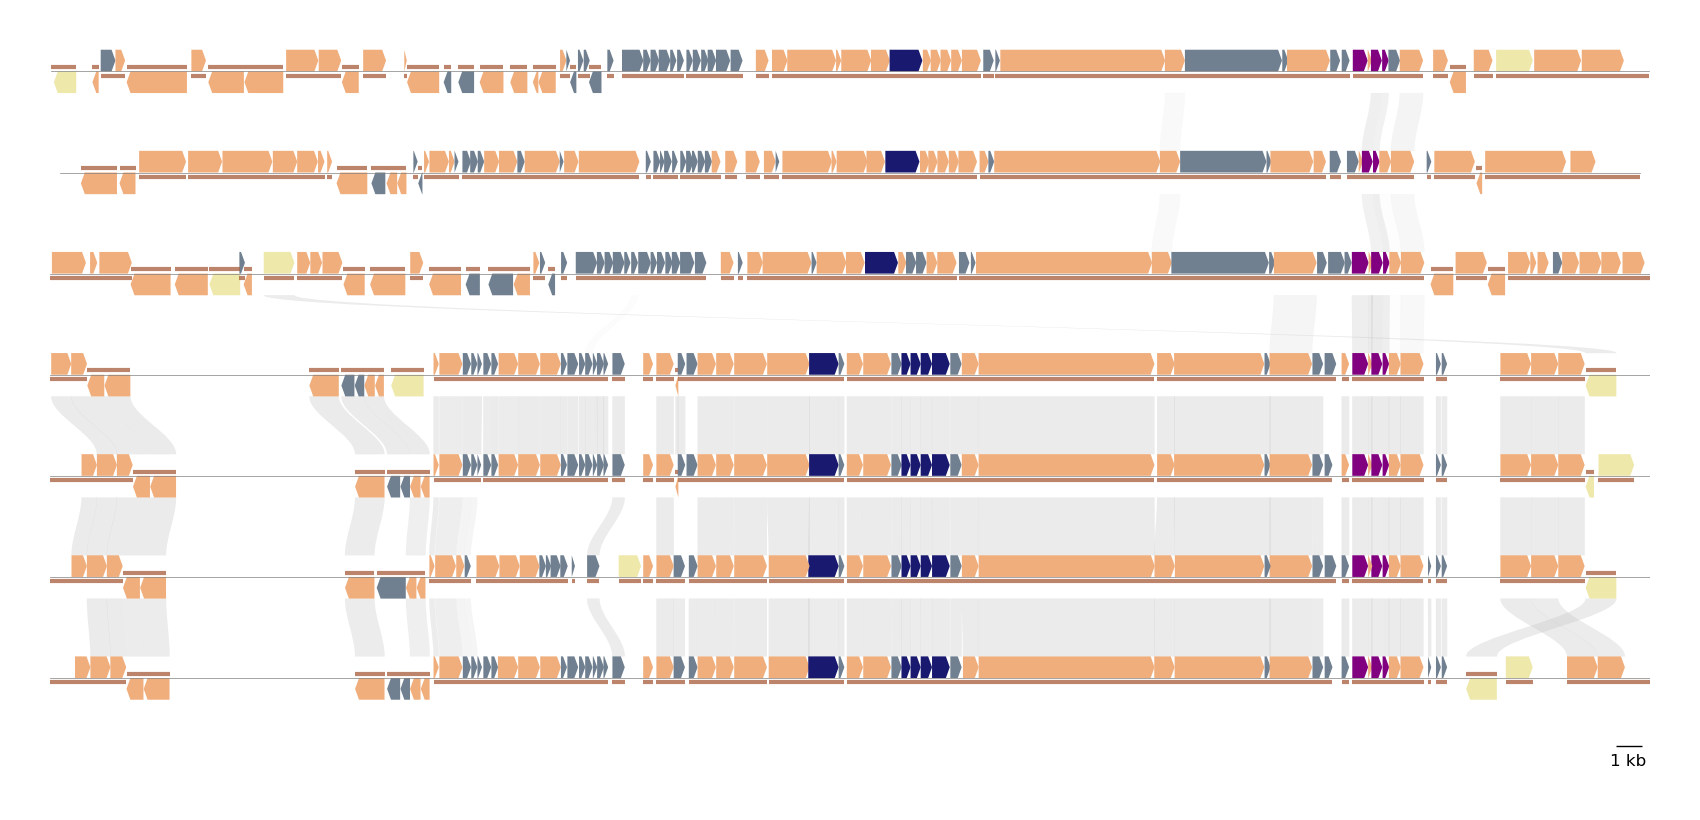

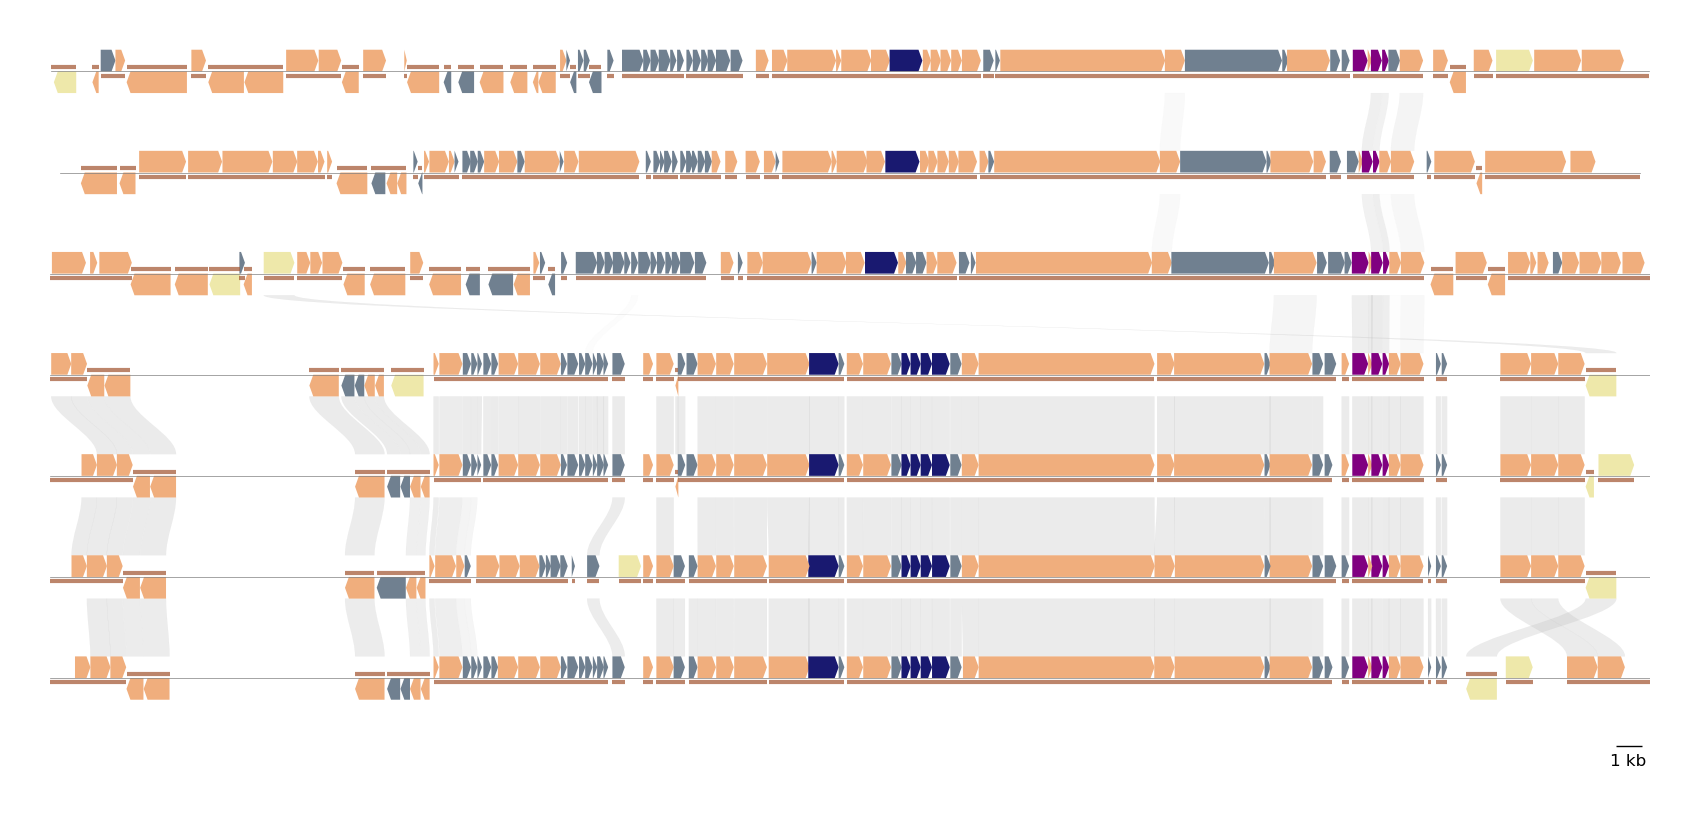

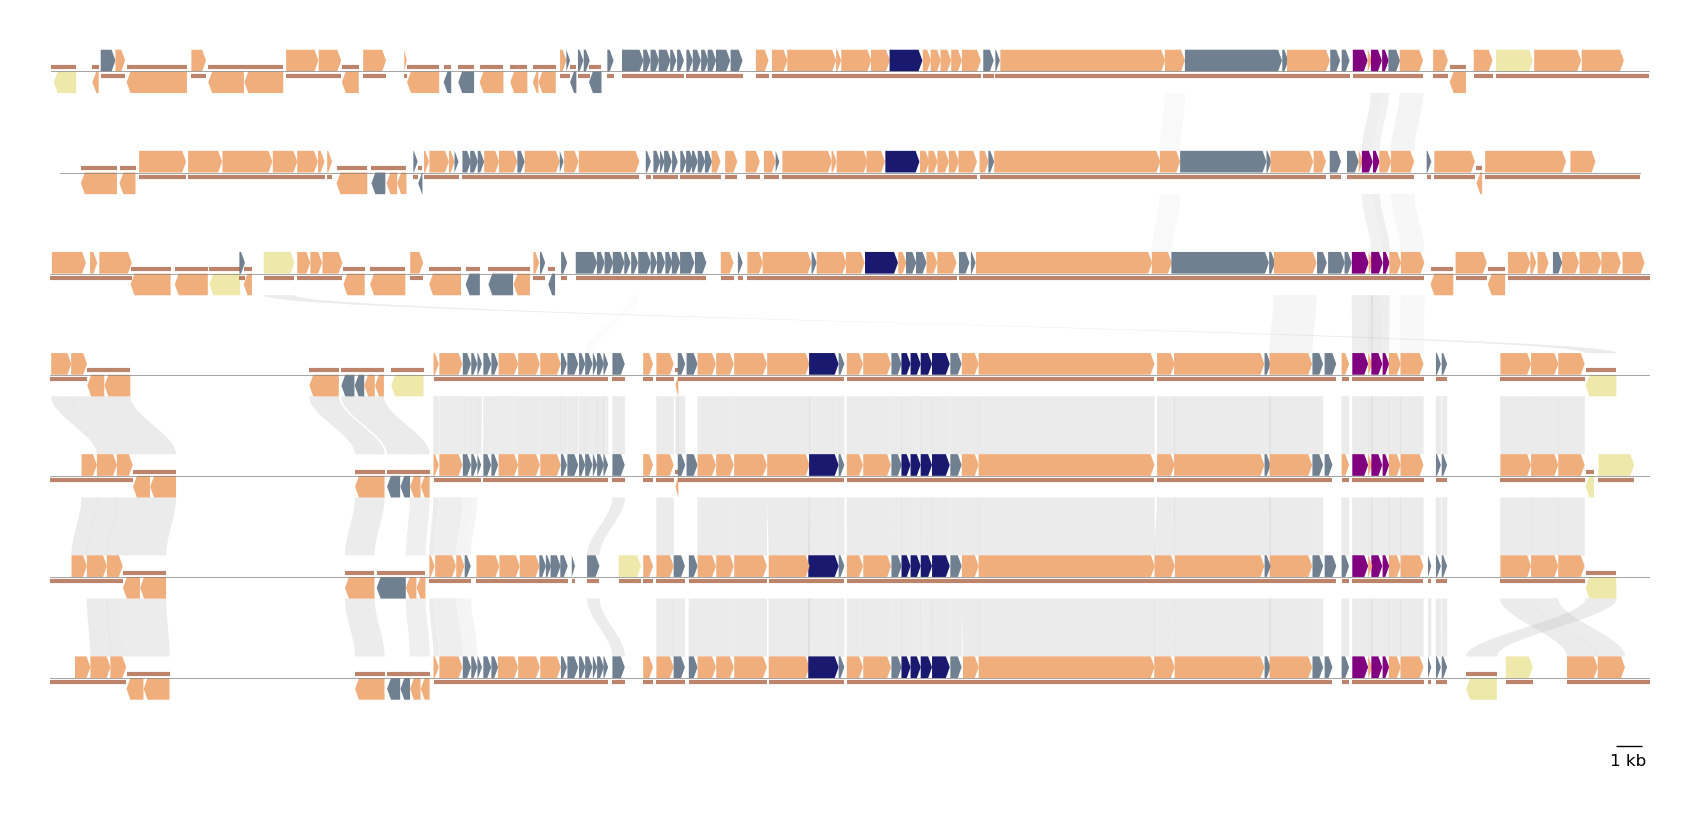

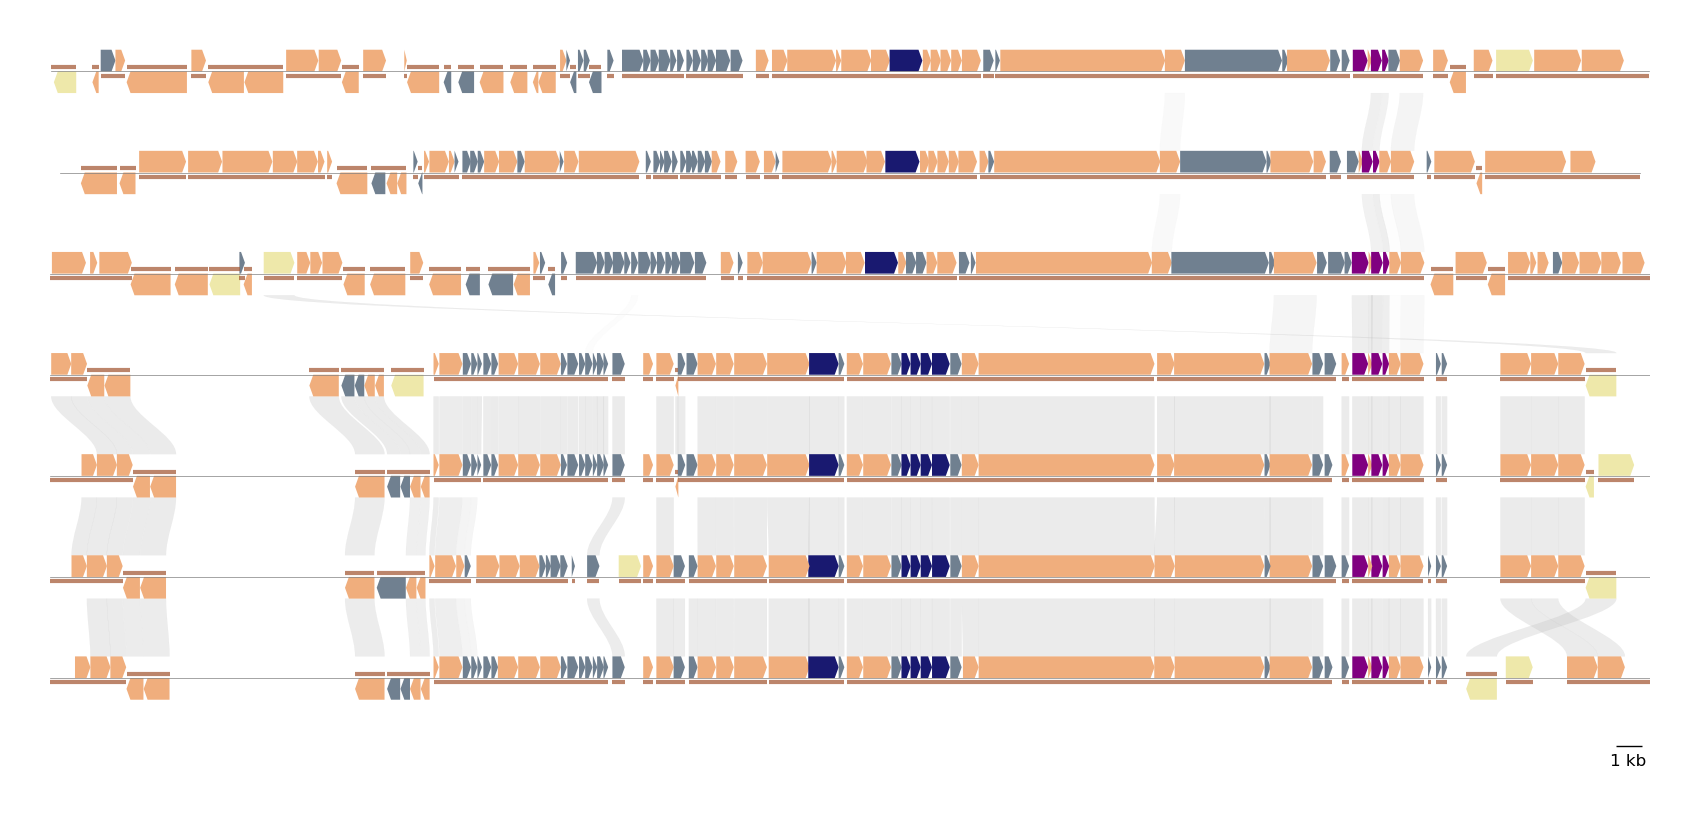

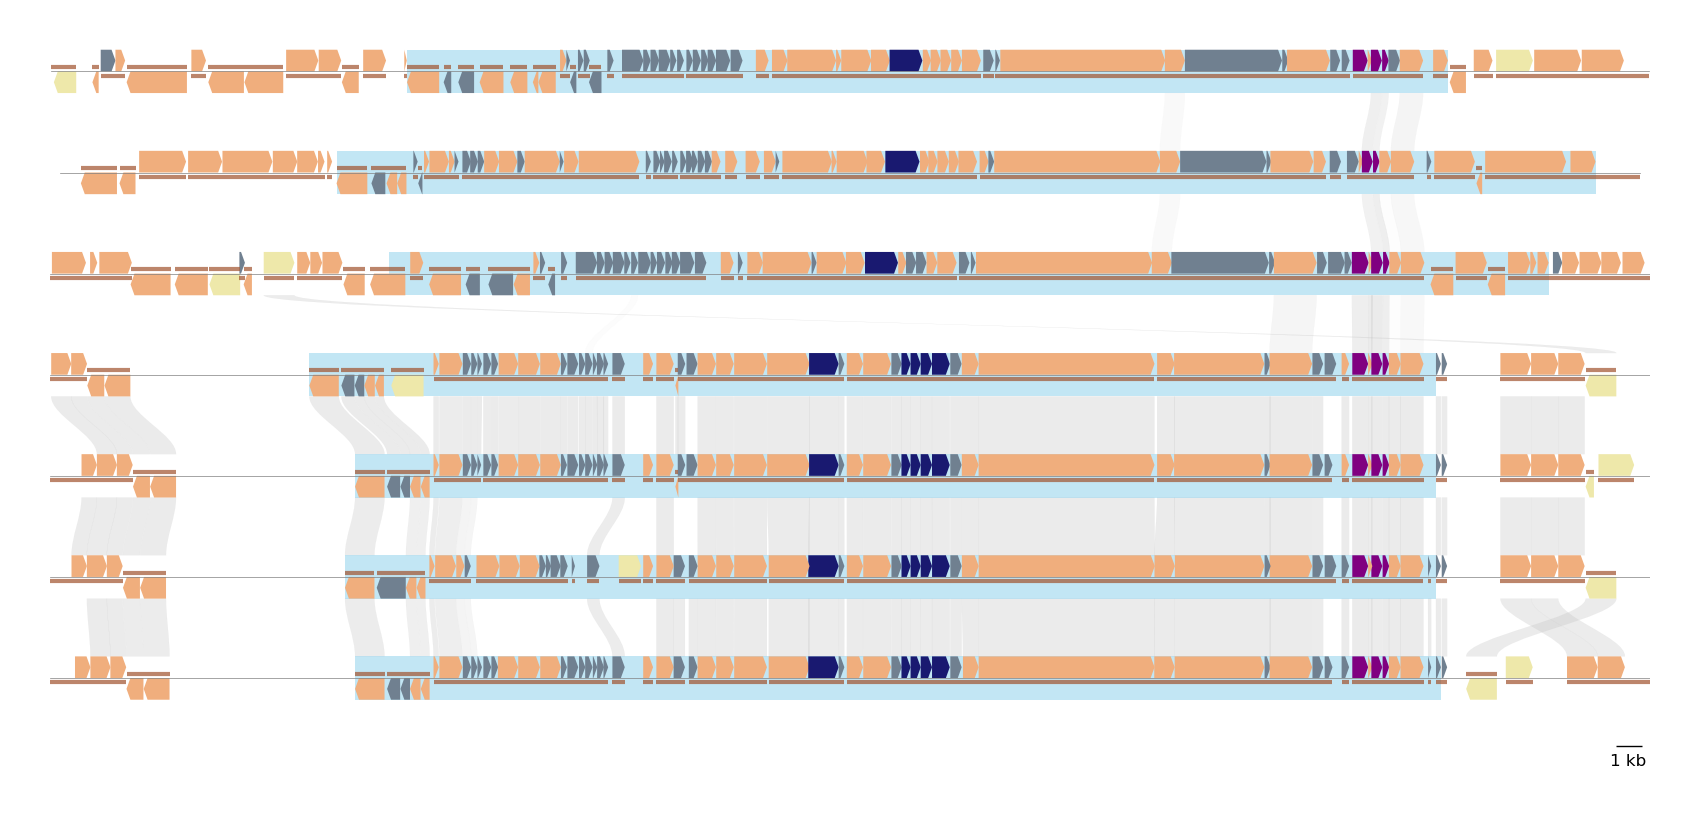

In [36]:
gene_list = ['ERR10897979.sbin.2_00762', 'ERR10897595.sbin.1_01051','ERR10897583.sbin.2_00776']
gbk_list = list(map(Genbank, gbk_files))

strains_with_genes = get_strains_with_genes(gene_list, gbk_list)
region_bounds = get_region_bounds(gene_list, gbk_list, strains_with_genes, window_size=50000)


for strain, (start, stop) in region_bounds.items():
   region_bounds[strain] = (start, stop-40000)
   
new_files = make_gbk_subset_files(region_bounds)


# new_files = [
#     'genomes_for_pyGenomeViz/Lc1700_subset_496961_558377.gbff',
#  'genomes_for_pyGenomeViz/Lc116_subset_390224_451640.gbff',
#  'genomes_for_pyGenomeViz/Lcr-MH175_subset_2151771_2213187.gbff',
#  'genomes_for_pyGenomeViz/VSI21_subset_497824_559240.gbff',
#  'genomes_for_pyGenomeViz/AB70_subset_1015066_1076254.gbff',
#    'genomes_for_pyGenomeViz/1D_subset_1050499_1111878.gbff',
#  'genomes_for_pyGenomeViz/2029_subset_1117323_1178003.gbff',
#  ]

align_coords, fig = plot_region(region_bounds, new_files, 
                                 plot_track_names=False, 
                                 plot_labels=False, 
                                 fig_width=16,
                                 operons_to_flip=['Lcr-MH175'], plot_phage=True)